# Business Case, Data Value and Narrative
The crime dataset that we chose has real data and is acquired from UCI Machine Learning repository where the title of the dataset is 'Crime and Communities'. The dataset has large number of numerical columns which was the main reason for choosing such a dataset rather than a categorical one because it makes is easy to apply algorithms and avoids the hassle of conversion of categorical data to numerical data. The crime attributes in the dataset that could be predicted by applying various machine learning algorithms as considered by the FBI are Rape, Murder, Larceny, Robbery, Assault, Burglaries, Autotheft and Arsons.

   The other columns in the dataset include information about community names, county codes, community codes, percent of the population considered urban, age based population, gender based population, race based population and so on which are useful factors to predict crimes. We used some features as predictors from the dataset to train the different models and created a binary label to predict the Occurence of Crime based on the selected features. We also calculated various metrics like accuracy, f1 score, rms value, confusion matrix for the various clustering, regression and classification algorithms that we applied to the dataset.
   
   The state column which was missing from the dataset was added to it based on the enrichment dataset viz cities.json available on the link below which contains mappings of latitude and longitude co-ordinates to their respective cities and states.

Base and Enrichment Dataset Location: https://www.kaggle.com/kkanda/analyzing-uci-crime-and-communities-dataset/data

## Loading the dataset into a Pandas Dataframe

In [61]:
!pip install graphviz
!pip install statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import graphviz
import statsmodels.api as sm
from patsy import dmatrices
from sklearn import datasets, linear_model, metrics, tree
from sklearn.model_selection import train_test_split # This line imports train_test_split
from sklearn.model_selection import cross_val_score # This line imports cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans

In [62]:
df = pd.read_csv('/content/crimedata.csv',sep= ',', encoding= "ISO-8859-1")

## Data Cleaning

The dataset 'crimedata.csv' was first loaded into a Pandas Dataframe and then some columns were renamed following appropriate naming conventions to make the data readable. Many columns had the character '?' which was replaced by 0 as part of data cleaning. Also, checks were placed to ensure that there were no '?' values at all after cleaning the data.

In [63]:
df=df.rename(columns = {'Êcommunityname':'Community Name'})
df = df.replace('?', '0')
df.head()

,crimeOccurence,Community Name,state,countyCode,communityCode,fold,population,householdsize,racepctblack,racePctWhite,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,ViolentCrimesPerPop,nonViolPerPop
0,1,BerkeleyHeightstownship,NJ,39,5320,1,11980,3.10,1.37,91.78,...,14,114.85,138,1132.08,16,131.26,2,16.41,41.02,1394.59
1,1,Marpletownship,PA,45,47616,1,23123,2.82,0.80,95.57,...,57,242.37,376,1598.78,26,110.55,1,4.25,127.56,1955.95
2,1,Tigardcity,OR,0,0,1,29344,2.43,0.74,94.33,...,274,758.14,1797,4972.19,136,376.3,22,60.87,218.59,6167.51
3,1,Gloversvillecity,NY,35,29443,1,16656,2.40,1.70,97.35,...,225,1301.78,716,4142.56,47,271.93,0,0,306.64,0
4,1,Bemidjicity,MN,7,5068,1,11245,2.76,0.53,89.16,...,91,728.93,1060,8490.87,91,728.93,5,40.05,0,9988.79


In [64]:
df.loc[df['countyCode'] == '?']
df.loc[df['ViolentCrimesPerPop'] == '?']

,crimeOccurence,Community Name,state,countyCode,communityCode,fold,population,householdsize,racepctblack,racePctWhite,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,ViolentCrimesPerPop,nonViolPerPop


## Criteria Based Label Creation

After studying the dataset carefully, we found out that predicting the occurence of a crime could be a useful and valuable usecase. But, to do so we had to create a label named 'violent_crime_occurence' based on the mean value from the column Violent Crimes Per Population. After calculating the mean and comparing the mean values with the available values in the column 'ViolentCrimesPerPop', a decision 'yes' or '1' was made that a crime has occured if the value in the corresponding column was greater than the mean value or 'no' or '0' if the value was less than the mean. Hence, a binary variable was created.

In [65]:
violent_crimes = list(map(float, df.ViolentCrimesPerPop))
violent_crimes_mean = sum(violent_crimes)/len(violent_crimes)
violent_crimes_mean

530.3040045146731

In [66]:
df['mean_violent_crimes'] = violent_crimes_mean
# Convert 'violent_crime_occurence' to numerical type during creation
df['violent_crime_occurence'] = np.where(violent_crimes>=df['mean_violent_crimes'], 1, 0)
# Now select numerical columns, including 'violent_crime_occurence'
numerical_df = df.select_dtypes(include=np.number)
numerical_df.groupby('violent_crime_occurence').mean()

,crimeOccurence,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,...,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,murders,murdPerPop,mean_violent_crimes
violent_crime_occurence,,,,,,,,,,,,,,,,,,,,,
0,0.847213,5.509979,32689.042670,2.707529,4.716284,90.651535,2.434721,4.499188,14.372340,27.183125,...,52.989732,77.301493,88.433861,20.915279,2383.545630,2.755100,0.433827,2.309704,2.775354,530.304005
1,0.829396,5.464567,92072.383202,2.706942,18.142375,71.258031,3.119226,14.530604,14.585984,28.525249,...,48.771535,77.620039,87.497874,39.823228,3547.116535,3.586522,2.021929,18.166667,11.739829,530.304005


## Data Slicing

In order to apply some clustering as well as classificatioj algorithms, the data needed to be sliced in order to better vizualise it and hence a temporary dataframe was created in order to do so which contained a slice of the actual data.

In [67]:
df1 = df.iloc[:200]
df1.head(200)

,crimeOccurence,Community Name,state,countyCode,communityCode,fold,population,householdsize,racepctblack,racePctWhite,...,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,ViolentCrimesPerPop,nonViolPerPop,mean_violent_crimes,violent_crime_occurence
0,1,BerkeleyHeightstownship,NJ,39,5320,1,11980,3.10,1.37,91.78,...,138,1132.08,16,131.26,2,16.41,41.02,1394.59,530.304005,0
1,1,Marpletownship,PA,45,47616,1,23123,2.82,0.80,95.57,...,376,1598.78,26,110.55,1,4.25,127.56,1955.95,530.304005,0
2,1,Tigardcity,OR,0,0,1,29344,2.43,0.74,94.33,...,1797,4972.19,136,376.3,22,60.87,218.59,6167.51,530.304005,0
3,1,Gloversvillecity,NY,35,29443,1,16656,2.40,1.70,97.35,...,716,4142.56,47,271.93,0,0,306.64,0,530.304005,0
4,1,Bemidjicity,MN,7,5068,1,11245,2.76,0.53,89.16,...,1060,8490.87,91,728.93,5,40.05,0,9988.79,530.304005,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1,LongBeachcity,CA,0,0,1,429433,2.70,13.68,58.38,...,14108,3235.53,7626,1748.95,243,55.73,1631.98,6595.13,530.304005,1
196,1,Duluthcity,MN,137,17000,1,85493,2.47,0.87,95.89,...,3266,3852.28,268,316.11,14,16.51,0,5198.1,530.304005,0
197,1,Shelbycity,NC,0,0,1,14669,2.41,42.50,57.03,...,937,5831.83,41,255.18,7,43.57,1419.06,8956.25,530.304005,1
198,1,Coronacity,CA,0,0,1,76095,3.18,2.76,75.88,...,3099,3319.23,1334,1428.8,23,24.63,519.47,6434.96,530.304005,0


## Feature Selection for Clustering Algorithms

In [68]:
features = ['householdsize', 'racepctblack']
X = df1[features].values
y = df1['violent_crime_occurence'].astype(float).values

## Plotting the actual data to vizualize it

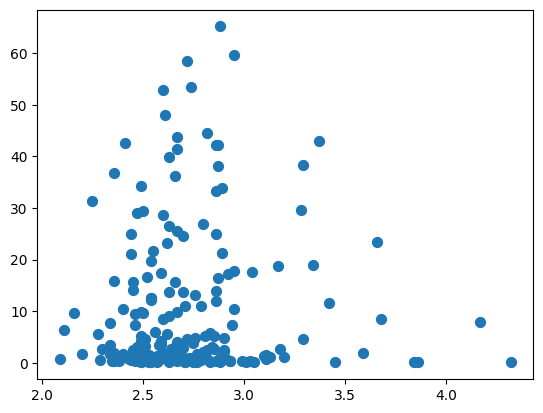

In [69]:
plt.scatter(X[:, 0], X[:, 1], s=50);

## Splitting the data

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Using the elbow method to find the optimal number of clusters

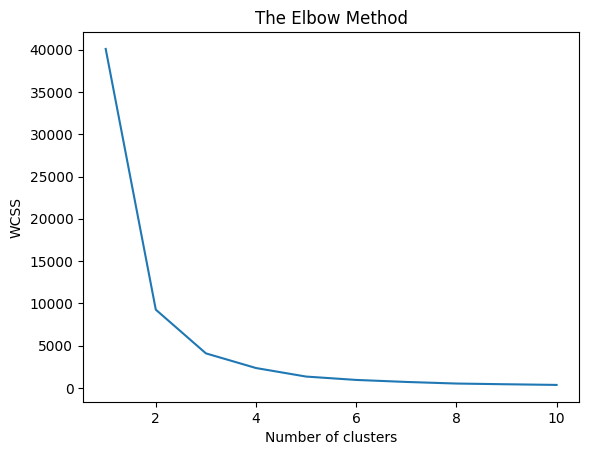

In [71]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans =KMeans(n_clusters =i, init = 'k-means++', max_iter =300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Applying kMeans Algorithm

In [72]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2)
kmeans.fit(X_train)
y_pred = kmeans.predict(X_test)

### Vizualising the clusters

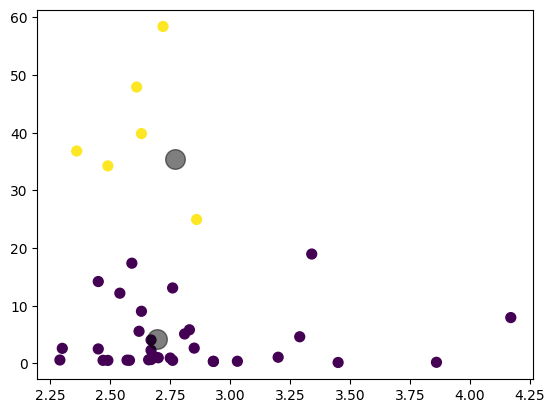

In [73]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

### Metrics Calculation

In [74]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # Import necessary metrics

kmeans = KMeans(n_clusters=2)
kmeans.fit(X_train)
y_pred = kmeans.predict(X_test)

kmeans_accuracy = accuracy_score(y_test, y_pred)
kmeans_precison=precision_score(y_test,y_pred,average=None)
kmeans_recall=recall_score(y_test,y_pred,average=None)
kmeans_f1=f1_score(y_test,y_pred,average=None)
kmeans_confusion_matrix = confusion_matrix(y_test, y_pred)

In [75]:
print("K-Means")
print("Scores")
print("Accuracy -->",kmeans_accuracy)
print("Precison -->",kmeans_precison)
print("Recall -->",kmeans_recall)
print("F1 -->",kmeans_f1)

print("Confusion Matrix")
print(kmeans_confusion_matrix)

K-Means
Scores
Accuracy --> 0.725
Precison --> [0.70588235 0.83333333]
Recall --> [0.96       0.33333333]
F1 --> [0.81355932 0.47619048]
Confusion Matrix
[[24  1]
 [10  5]]


## Applying GMM


### Data Cleaning

In [76]:
#converting huge ranges of data to average values
def extractSubstring(myStr):
    if "-" in myStr :
        lowVal,hiVal = myStr.split("-")

        lowVal = re.sub(r'[^\w]', '', lowVal)
        hiVal = re.sub(r'[^\w]', '', hiVal)

        lowVal = atof(lowVal)
        hiVal = atof(hiVal)
        lowV = float(lowVal)
        hiV = float(hiVal)
        average = (lowV + hiV)/2
    else:
        lowVal = myStr
        average = convert_to_float(lowVal)

    return average

def convert_to_float(input_str):
    return float(input_str.replace(",",""))

df['PolicReqPerOffic'] = df['PolicReqPerOffic'].apply(extractSubstring)
df['ViolentCrimesPerPop'] = df['ViolentCrimesPerPop'].apply(extractSubstring)

### Feature selection

In [77]:
Features = ['PolicReqPerOffic','ViolentCrimesPerPop']
X = df[Features].values

### Applying GMM
The intent is to cluster the dataset based on Violent crimes per population and for crimes occuring what number of police are required to control and handle the crime.

In [78]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3).fit(X)
labels = gmm.predict(X)

### Vizualising the clusters

Text(0.5, 1.0, 'GMM Clustering')

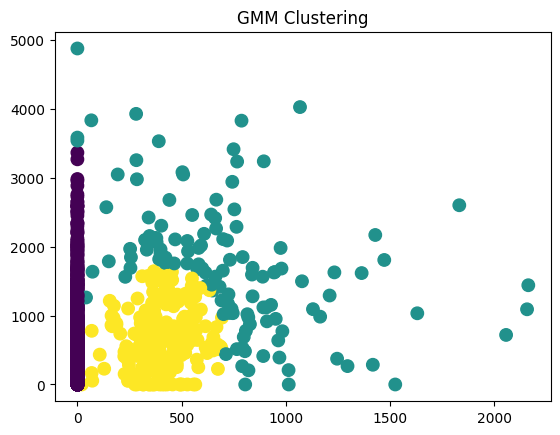

In [79]:
plt.scatter(X[:, 0], X[:, 1], c=labels, s=80, cmap='viridis');
plt.title("GMM Clustering")

## Linear Regression

### Feature Selection

In [80]:
X1 = df[['PctUnemployed']].astype(int).values
y1 = df['ViolentCrimesPerPop'].astype(int).values

### Splitting the data

In [81]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=0)

### Fitting the model

In [82]:
from sklearn import datasets, linear_model
regr = linear_model.LinearRegression()
regr.fit(X1_train, y1_train)

LinearRegression()

### Predicting the values

In [83]:
y_pred = regr.predict(X1_test)

### Vizualisation of plots

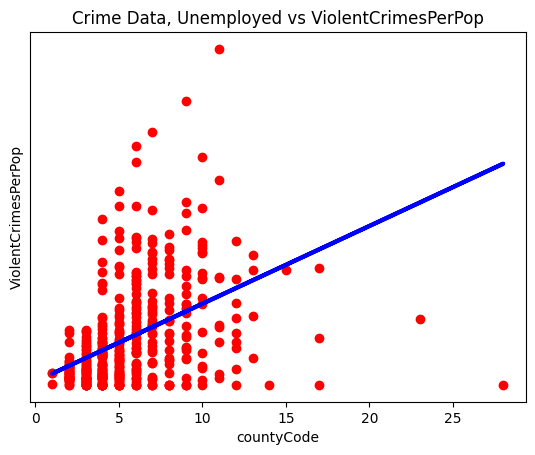

In [84]:
plt.scatter(X1_test, y1_test,  color='red')
plt.plot(X1_test, y_pred, color='blue', linewidth=3)

plt.title('Crime Data, Unemployed vs ViolentCrimesPerPop')
plt.xlabel('countyCode')
plt.ylabel('ViolentCrimesPerPop')

plt.yticks(())
plt.show()

## Logistic Regression

In [85]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from patsy import dmatrices
from sklearn.linear_model import LogisticRegression
# Instead of these imports:
# from sklearn.cross_validation import train_test_split
# from sklearn.cross_validation import cross_val_score

# Use these imports:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

### Data Slicing

In [86]:
df1 = df.iloc[:200]

### Visualizing Selected Features by plotting their Histograms

In [87]:
age12t21 = df1['agePct12t21'].astype(int)

In [88]:
age12t21.replace('?','0', inplace = True)

<function matplotlib.pyplot.show(close=None, block=None)>

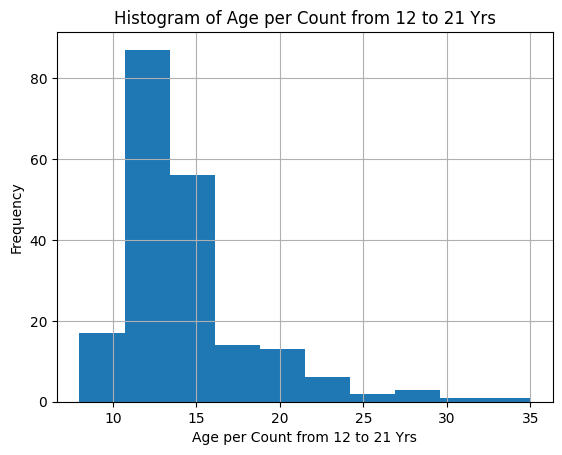

In [89]:
%matplotlib inline
age12t21.hist()
plt.title('Histogram of Age per Count from 12 to 21 Yrs')
plt.xlabel('Age per Count from 12 to 21 Yrs')
plt.ylabel('Frequency')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

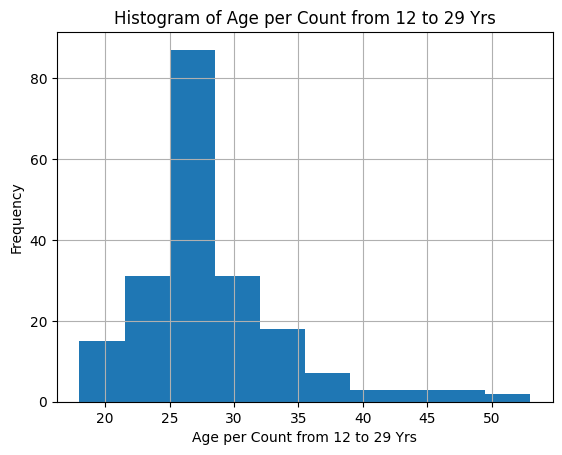

In [90]:
age12t29 = df1['agePct12t29'].astype(int)
%matplotlib inline
age12t29.hist()
plt.title('Histogram of Age per Count from 12 to 29 Yrs')
plt.xlabel('Age per Count from 12 to 29 Yrs')
plt.ylabel('Frequency')
plt.show

### Plotting the features to analyze the label and its frequency

<function matplotlib.pyplot.show(close=None, block=None)>

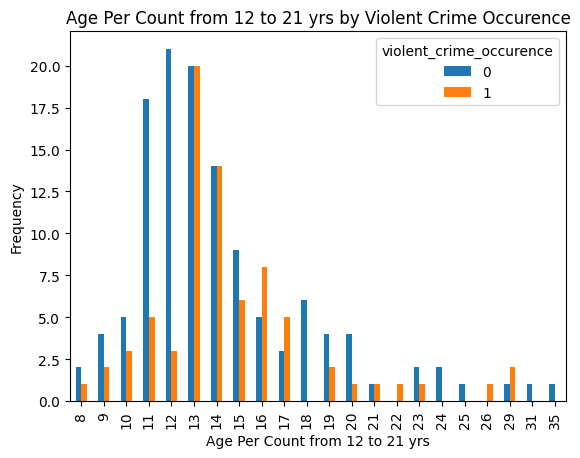

In [91]:
pd.crosstab(age12t21, df1.violent_crime_occurence).plot(kind='bar')
plt.title('Age Per Count from 12 to 21 yrs by Violent Crime Occurence')
plt.xlabel('Age Per Count from 12 to 21 yrs')
plt.xticks(rotation='vertical')
plt.ylabel('Frequency')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

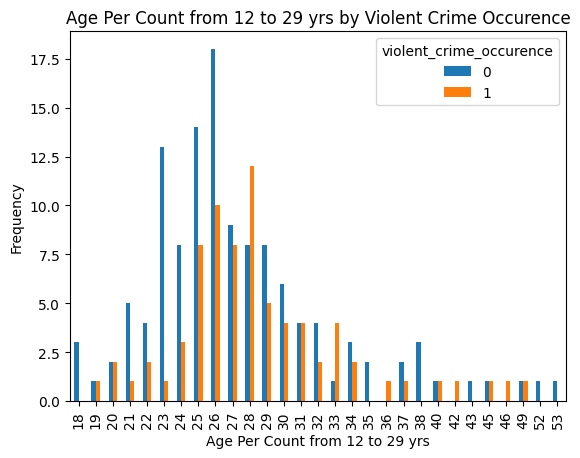

In [92]:
pd.crosstab(age12t29, df1.violent_crime_occurence).plot(kind='bar')
plt.title('Age Per Count from 12 to 29 yrs by Violent Crime Occurence')
plt.xlabel('Age Per Count from 12 to 29 yrs')
plt.xticks(rotation='vertical')
plt.ylabel('Frequency')
plt.show

In [93]:
X_LogReg= ['agePct12t21','agePct12t29','agePct16t24', 'agePct65up', 'PctUnemployed', 'murdPerPop', 'MalePctDivorce']

In [94]:
y_LogReg = df1[['violent_crime_occurence']]

### Training the Model

In [95]:
X_train_LogReg, X_test_LogReg, y_train_LogReg, y_test_LogReg = train_test_split(df1[X_LogReg], y_LogReg, test_size=0.2, random_state=0)

In [96]:
logreg = LogisticRegression()
logreg.fit(X_train_LogReg, y_train_LogReg)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

### Metrics

In [97]:
y_pred_LogReg = logreg.predict(X_test_LogReg)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test_LogReg, y_test_LogReg)))

Accuracy of logistic regression classifier on test set: 0.80


### Creating the Confusion Matrix to make further conclusion

Model Accuracy for Logistic Regression: 0.8


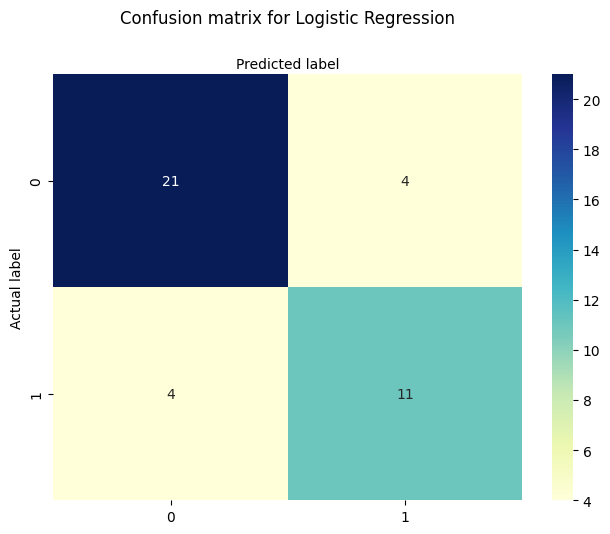

In [98]:
cnf_matrix_LogitRegression = metrics.confusion_matrix(y_test_LogReg, y_pred_LogReg)
cnf_matrix_LogitRegression

class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_LogitRegression), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix for Logistic Regression', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
print("Model Accuracy for Logistic Regression:",metrics.accuracy_score(y_test_LogReg, y_pred_LogReg))


## Decision Tree

Using Decision Tree Classifier from sklearn, we are trying to predict whether a crime has occured based on certain features or not and then calculating the accuracy of the decision tree classifier after training and testing the model.

In [99]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

In [100]:
#X = balance_data.values[:, [5,6,17,37,47,50,56,96,129,131,133,135,137,139,141,143,145]]
df = df[['population','householdsize','medIncome','PctUnemployed','PolicReqPerOffic','murders','rapes','burglaries','robberies','violent_crime_occurence']]
df = df
X_DecisionTree = df.drop('violent_crime_occurence', axis=1)
Y_DecisionTree = df['violent_crime_occurence']

In [101]:
from sklearn.model_selection import train_test_split
X_train_DecisionTree, X_test_DecisionTree, Y_train_DecisionTree, Y_test_DecisionTree = train_test_split(X_DecisionTree, Y_DecisionTree, random_state=1)

### Implementing Decision Tree Classifier

In [102]:
clf_gini = DecisionTreeClassifier(criterion = "gini", random_state = 100,max_depth=20, min_samples_split=9, min_samples_leaf=6)
clf_gini

DecisionTreeClassifier(max_depth=20, min_samples_leaf=6, min_samples_split=9,
                       random_state=100)

In [103]:
clf_gini.fit(X_train_DecisionTree, Y_train_DecisionTree)

DecisionTreeClassifier(max_depth=20, min_samples_leaf=6, min_samples_split=9,
                       random_state=100)

In [104]:
Y_Pred_DecisionTree = clf_gini.predict(X_test_DecisionTree)
Y_Pred_DecisionTree

array([0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,

### Metrics

In [105]:
ac=accuracy_score(Y_test_DecisionTree, Y_Pred_DecisionTree)*100
ac

85.5595667870036

### Plotting the tree

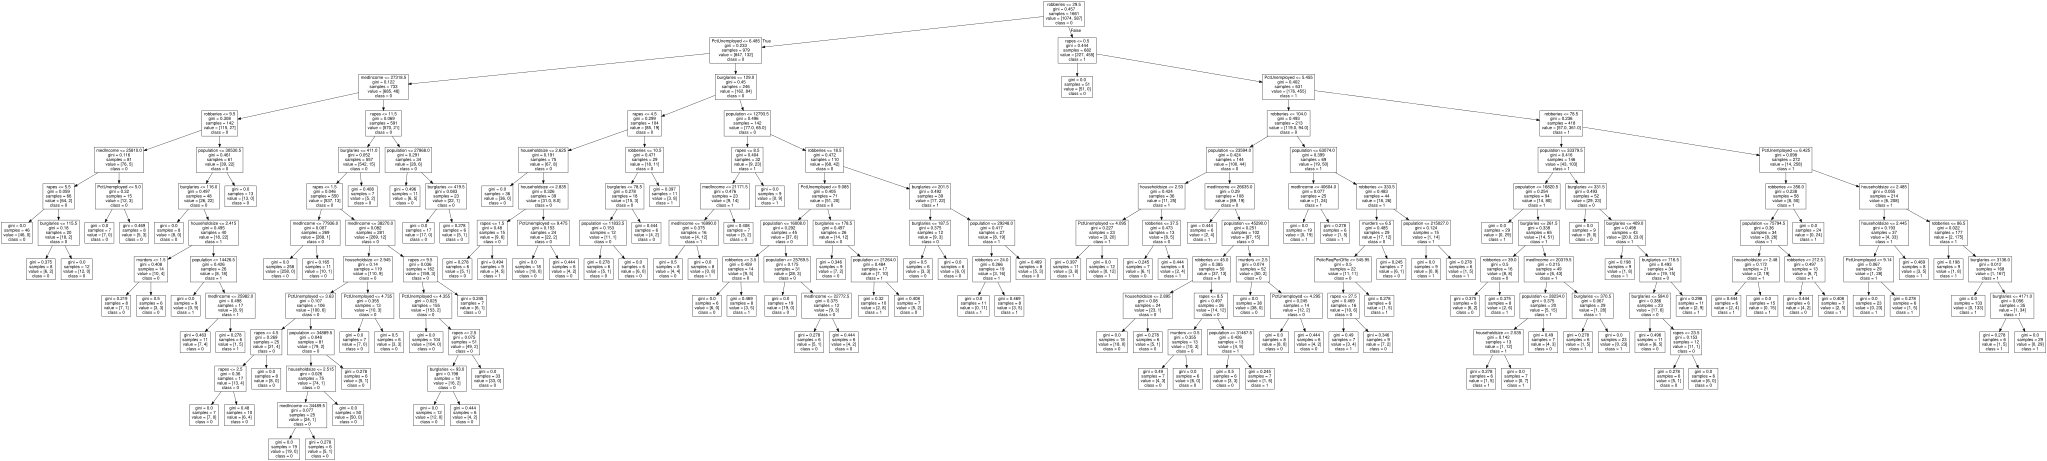

In [106]:
import graphviz
dot_data = tree.export_graphviz(clf_gini, out_file=None, feature_names=X_DecisionTree.columns, class_names=['0','1'])
graph = graphviz.Source(dot_data)
graph.render("crime")
graph

### Confusion Matrix

Model Accuracy for Random Forest: 0.855595667870036


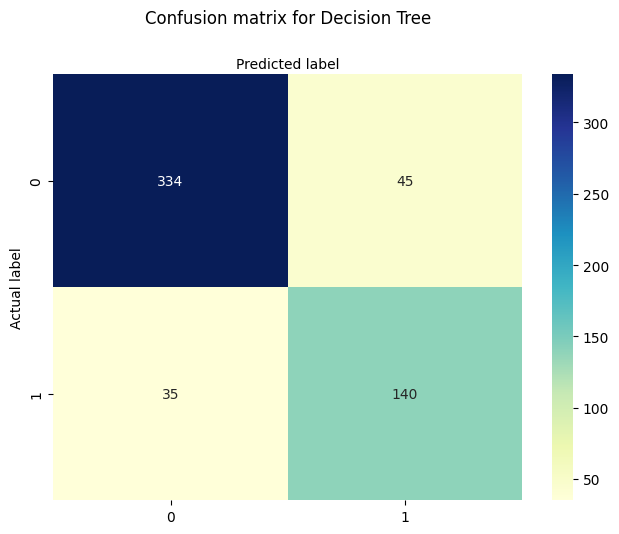

In [107]:
# For Decision Tree
cnf_matrix_DecisionTree = metrics.confusion_matrix(Y_test_DecisionTree, Y_Pred_DecisionTree)
cnf_matrix_DecisionTree
# name  of classes
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_DecisionTree), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix for Decision Tree', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
print("Model Accuracy for Random Forest:",metrics.accuracy_score(Y_test_DecisionTree, Y_Pred_DecisionTree))

In [108]:
## Gaussian Naive Bayes Classifier

### Label Creation

In [109]:
murder = list(map(float, df.murders)) # Change 'murdPerPop' to 'murders'
murders_mean = sum(murder)/len(murder)
murders_mean

7.764785553047404

In [110]:
# Calculate the mean of the murder column
import numpy as np  # Import numpy if not already imported

murders_mean = np.mean(murder)  # Use np.mean() to calculate the mean of the list
df['mean_murder'] = murders_mean

# Create binary classification for murder occurrence
df['murder_occurence'] = np.where(murder >= df['mean_murder'], 1, 0)

# Only include numeric columns in the groupby mean
numeric_cols = df.select_dtypes(include=[np.number]).columns # Define numeric_cols before using it


# Convert relevant columns to numeric (handle coercion)
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

grouped_means = df[numeric_cols].groupby(df['murder_occurence']).mean()

grouped_means

,population,householdsize,medIncome,PctUnemployed,PolicReqPerOffic,murders,violent_crime_occurence,mean_murder,murder_occurence
murder_occurence,,,,,,,,,
0,28061.089048,2.701571,34951.793245,5.741965,36.761771,1.119754,0.275844,7.764786,0.0
1,240708.685824,2.750421,26744.436782,8.315747,412.959004,57.513410,0.854406,7.764786,1.0


### Data Slicing

In [111]:
# Create a new DataFrame with selected features and rows, using the original DataFrame if necessary
original_df = pd.read_csv('crimedata.csv',sep= ',', encoding= "ISO-8859-1")  # Reload the original data if 'df' has been modified

# Create the 'murder_occurence' column in original_df (similar to how you did it in df)
murder = list(map(float, original_df['murders']))  # Assuming 'murders' is the correct column name
murders_mean = sum(murder) / len(murder)
original_df['mean_murder'] = murders_mean
original_df['murder_occurence'] = np.where(murder >= original_df['mean_murder'], 1, 0)


df1 = original_df[['agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'PctUnemployed', 'murder_occurence']].iloc[:700]  # Select columns first, then slice rows

In [112]:
X_NaiveBayes= ['agePct12t21','agePct12t29','agePct16t24', 'agePct65up','PctUnemployed']
Y_NaiveBayes = df1[['murder_occurence']]

In [113]:
# Create a new DataFrame with selected features and rows, using the original DataFrame if necessary
original_df = pd.read_csv('crimedata.csv',sep= ',', encoding= "ISO-8859-1")  # Reload the original data if 'df' has been modified

# Create the 'murder_occurence' column in original_df (similar to how you did it in df)
murder = list(map(float, original_df['murders']))  # Assuming 'murders' is the correct column name
murders_mean = sum(murder) / len(murder)
original_df['mean_murder'] = murders_mean
original_df['murder_occurence'] = np.where(murder >= original_df['mean_murder'], 1, 0)


# Instead of using iloc, directly select the columns and then slice rows using loc or head()
df1 = original_df[['agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'PctUnemployed', 'murder_occurence']].head(700)  # Using head() to get the first 700 rows
#OR
df1 = original_df.loc[:699, ['agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'PctUnemployed', 'murder_occurence']]  # Using loc to select rows and columns

In [114]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

In [115]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Load the dataset
original_df = pd.read_csv('crimedata.csv', sep=',', encoding="ISO-8859-1")

# Create the 'murder_occurence' column
murder = list(map(float, original_df['murders']))
murders_mean = sum(murder) / len(murder)
original_df['mean_murder'] = murders_mean
original_df['murder_occurence'] = np.where(murder >= original_df['mean_murder'], 1, 0)

# Select features and target variable
X_NaiveBayes = original_df[['agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'PctUnemployed']]
Y_NaiveBayes = original_df[['murder_occurence']]

# Split the data into training and testing sets
X_train_NaiveBayes, X_test_NaiveBayes, Y_train_NaiveBayes, Y_test_NaiveBayes = train_test_split(
    X_NaiveBayes, Y_NaiveBayes, test_size=0.3, random_state=0
)  # Adjust test_size and random_state as needed

# Create and train the Gaussian Naive Bayes model
model = GaussianNB()
model.fit(X_train_NaiveBayes, Y_train_NaiveBayes.values.ravel())  # Use ravel() to avoid warning

# Now you can proceed with model evaluation and predictions
# ...

GaussianNB()

### Model Accuracy

In [116]:
Y_Pred_NaiveBayes = model.predict(X_test_NaiveBayes)
print('Accuracy of Gaussian Naive Bayes classifier on test set: {:.2f}'.format(model.score(X_test_NaiveBayes, Y_test_NaiveBayes)))

Accuracy of Gaussian Naive Bayes classifier on test set: 0.81


### Corelation matrix showing the features

In [117]:
df1[df1.columns.intersection(X_NaiveBayes.columns)].corr()

,agePct12t21,agePct12t29,agePct16t24,agePct65up,PctUnemployed
agePct12t21,1.000000,0.857899,0.923780,-0.362218,0.219374
agePct12t29,0.857899,1.000000,0.946554,-0.484518,0.159712
agePct16t24,0.923780,0.946554,1.000000,-0.288004,0.141656
agePct65up,-0.362218,-0.484518,-0.288004,1.000000,0.131281
PctUnemployed,0.219374,0.159712,0.141656,0.131281,1.000000


### Corelation Heatmap for better visualization

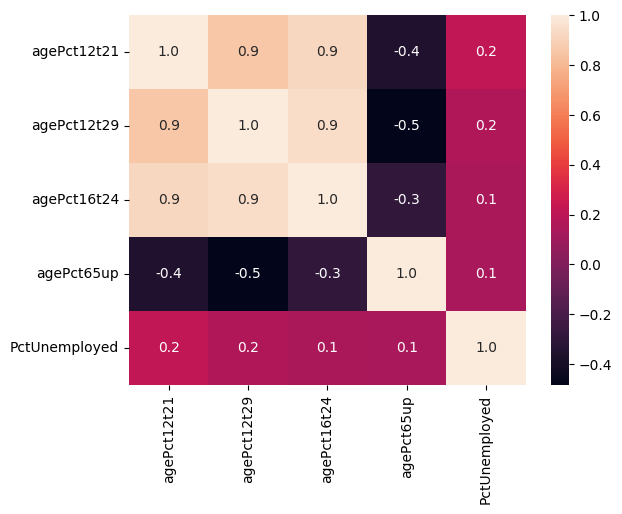

In [118]:
import seaborn as sns
sns.heatmap(df1[df1.columns.intersection(X_NaiveBayes.columns)].corr(), annot=True, fmt=".1f")
plt.show()

## Confusion Matrix

Model Accuracy for Random Forest: 0.8135338345864662


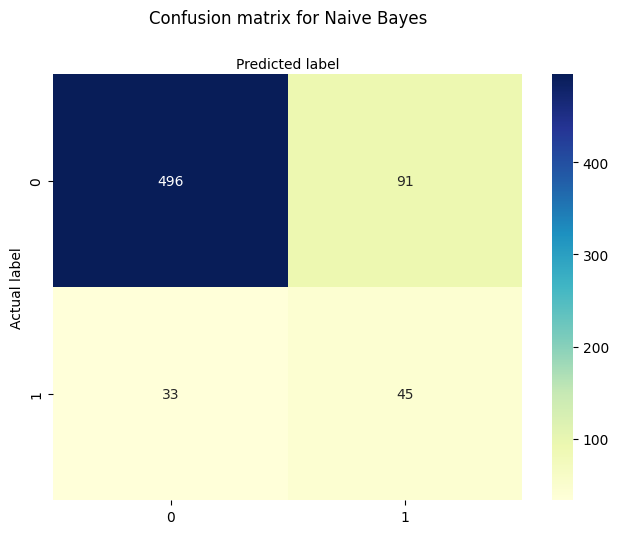

In [119]:
cnf_matrix_NaiveBayes = metrics.confusion_matrix(Y_test_NaiveBayes, Y_Pred_NaiveBayes)
cnf_matrix_NaiveBayes
# name  of classes
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_NaiveBayes), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix for Naive Bayes', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
print("Model Accuracy for Random Forest:",metrics.accuracy_score(Y_test_NaiveBayes, Y_Pred_NaiveBayes))

## Random Forest Classifier

### Label Creation

In [120]:
# Convert relevant columns to numeric (handle coercion)
for col in df.columns:
    if col != 'Community Name':  # Exclude the 'Community Name' column if it's not numeric
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except ValueError:
            print(f"Warning: Could not convert column '{col}' to numeric.")

# Now calculate the mean after converting to numeric
df.groupby('violent_crime_occurence').mean()

,population,householdsize,medIncome,PctUnemployed,PolicReqPerOffic,murders,rapes,burglaries,robberies,mean_murder,murder_occurence
violent_crime_occurence,,,,,,,,,,,
0,32689.042670,2.707529,37667.596008,5.217233,34.428080,2.309704,7.673778,313.911906,61.982794,7.764786,0.026153
1,92072.383202,2.706942,26962.053806,7.624108,170.066667,18.166667,59.237533,1611.209974,573.182415,7.764786,0.292651


### Feature Selection

In [121]:
df = df[['population','householdsize','medIncome','PctUnemployed','PolicReqPerOffic','murders','rapes','burglaries','robberies','violent_crime_occurence']]
df = df
X = df.drop('violent_crime_occurence', axis=1)
y = df['violent_crime_occurence']

In [122]:
X_train_RandomForest, X_test_RandomForest, Y_train_RandomForest, Y_test_RandomForest = train_test_split(X, y, random_state=1)

### Calculating gini index for Random Forest Classifier

In [123]:
from sklearn.ensemble import RandomForestClassifier
clf_gini = RandomForestClassifier(criterion = "gini",random_state = 200,max_depth=30, min_samples_split=9, min_samples_leaf=6)
clf_gini

RandomForestClassifier(max_depth=30, min_samples_leaf=6, min_samples_split=9,
                       random_state=200)

### Fitting and predicitng the model

In [124]:
clf_gini.fit(X_train_RandomForest, Y_train_RandomForest)

RandomForestClassifier(max_depth=30, min_samples_leaf=6, min_samples_split=9,
                       random_state=200)

In [125]:
Y_Pred_RandomForest = clf_gini.predict(X_test_RandomForest)

### Metrics

In [126]:
ac=accuracy_score(Y_test_RandomForest,Y_Pred_RandomForest)*100
ac

86.46209386281588

### Confusion Matrix

In [127]:
cnf_matrix_RandomForest = metrics.confusion_matrix(Y_test_RandomForest, Y_Pred_RandomForest)
cnf_matrix_RandomForest

array([[347,  32],
       [ 43, 132]])

Model Accuracy for Random Forest: 0.8646209386281588


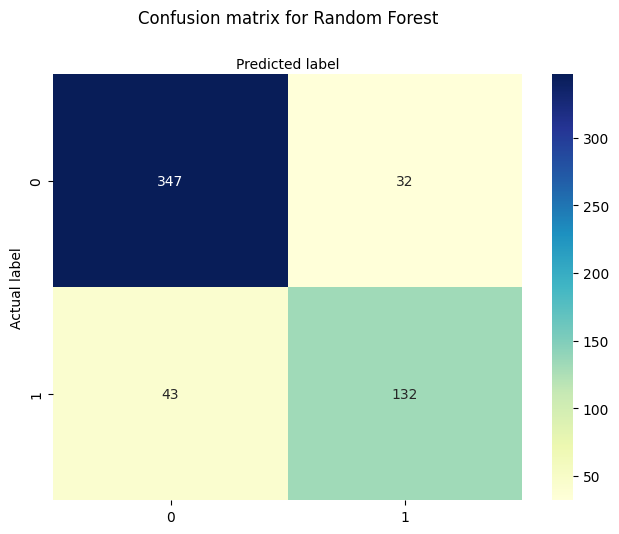

In [128]:
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_RandomForest), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix for Random Forest', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
print("Model Accuracy for Random Forest:",metrics.accuracy_score(Y_test_RandomForest, Y_Pred_RandomForest))

## SVM

In [129]:
# Load original DataFrame or ensure original columns are present
original_df = pd.read_csv('crimedata.csv', sep=',', encoding="ISO-8859-1")  # Assuming 'crimedata.csv' is your original data

# Replace '?' with NaN before converting to float
original_df['ViolentCrimesPerPop'] = original_df['ViolentCrimesPerPop'].replace('?', np.nan)


# Create the 'violent_crime_occurence' column in original_df
# (Similar logic as you did earlier in your code)
violent_crimes = list(map(float, original_df['ViolentCrimesPerPop'].dropna()))  # Drop NaN values
violent_crimes_mean = sum(violent_crimes) / len(violent_crimes)
original_df['mean_violent_crimes'] = violent_crimes_mean
original_df['violent_crime_occurence'] = np.where(original_df['ViolentCrimesPerPop'].astype(float) >= original_df['mean_violent_crimes'], 1, 0)

# Check if columns are in the DataFrame
if all(col in original_df.columns for col in ['racePctWhite', 'racepctblack', 'racePctHisp']):
    # If columns are present in the original DataFrame, select them
    df2 = original_df[['population', 'householdsize', 'racePctWhite', 'racepctblack', 'racePctHisp', 'medIncome', 'PctUnemployed', 'PolicReqPerOffic', 'murders', 'rapes', 'burglaries', 'robberies', 'violent_crime_occurence']]
else:
    # If columns are not present, print a warning or handle it appropriately
    print("Error: Columns 'racePctWhite', 'racepctblack', 'racePctHisp' not found in the DataFrame.")
    # You might need to adjust your feature selection based on available columns

In [130]:
X_SVM = df2.iloc[:, [3, 4]].values
Y_SVM = df2.iloc[:, 12].values

### Splitting the dataset into the Training set and Test set

In [131]:
from sklearn.model_selection import train_test_split # Import train_test_split from model_selection
X_train_SVM, X_test_SVM, Y_train_SVM, Y_test_SVM = train_test_split(X_SVM, Y_SVM, test_size = 0.30, random_state = 0)

### Feature Scaling

In [132]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_SVM = sc.fit_transform(X_train_SVM)
X_test_SVM = sc.transform(X_test_SVM)
print(X_train_SVM)

[[ 0.557996   -0.49362092]
 [-0.58847309 -0.28112885]
 [-0.62648141  3.73638802]
 ...
 [-0.27887807  1.55338608]
 [-0.55737538 -0.35266784]
 [ 0.01551364  0.09498213]]


### Training & fitting the model

In [133]:
# Fitting SVM to the Training set
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear',random_state = 0)
classifier.fit(X_train_SVM, Y_train_SVM)

SVC(kernel='linear', random_state=0)

In [134]:
Y_Pred_SVM = classifier.predict(X_test_SVM)

The support vectors for the model are as follows


In [135]:
print(classifier.support_vectors_)

[[-0.62648141  3.73638802]
 [ 0.5282804  -0.43128991]
 [-0.24847141  0.92865938]
 ...
 [ 0.69275276 -0.09059428]
 [-0.27887807  1.55338608]
 [ 0.01551364  0.09498213]]


### Confusion Matrix

Model Accuracy for SVM: 0.8120300751879699


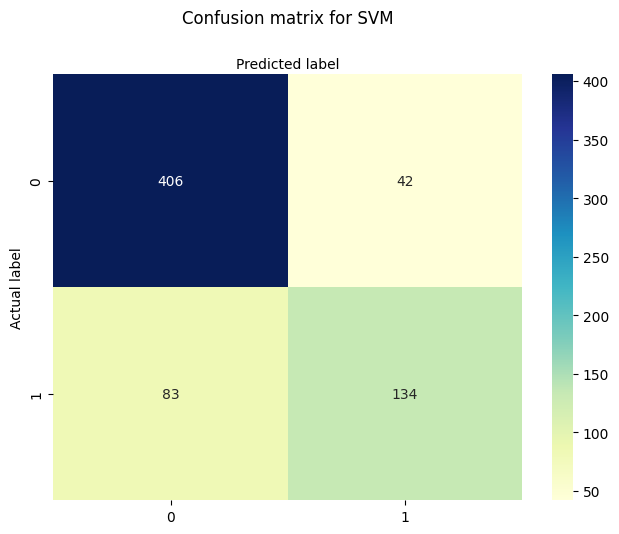

In [136]:
cnf_matrix_RandomForest = metrics.confusion_matrix(Y_test_SVM, Y_Pred_SVM)
cnf_matrix_RandomForest
# name  of classes
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_RandomForest), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix for SVM', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
print("Model Accuracy for SVM:",metrics.accuracy_score(Y_test_SVM, Y_Pred_SVM))


### Accuracy

In [137]:
ac=accuracy_score(Y_test_SVM,Y_Pred_SVM)*100
ac

81.203007518797

### Vizualising model results

<ipython-input-138-9b9f68128a2b>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


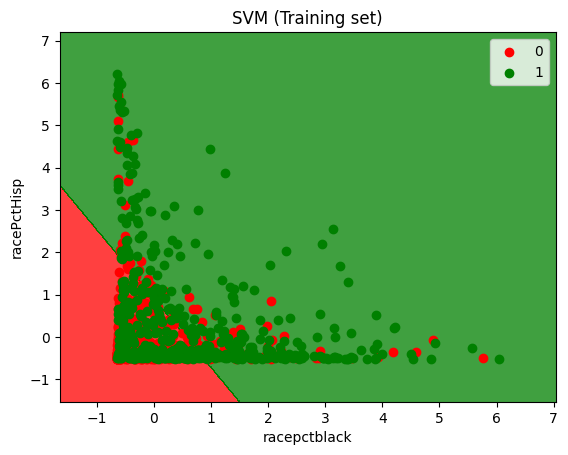

In [138]:
# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train_SVM, Y_train_SVM
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Training set)')
plt.xlabel('racepctblack')
plt.ylabel('racePctHisp')
plt.legend()
plt.show()

<ipython-input-139-f65ca2f35c2c>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


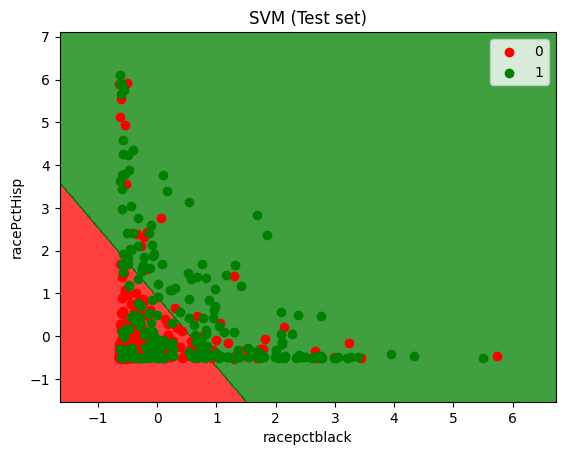

In [139]:
# Visualising the Test set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_test_SVM, Y_test_SVM
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Test set)')
plt.xlabel('racepctblack')
plt.ylabel('racePctHisp')
plt.legend()
plt.show()

### Fitting SVM to the Training set

In [140]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf',random_state = 0)
classifier.fit(X_train_SVM, Y_train_SVM)

SVC(random_state=0)

In [141]:
Y_Pred_SVMrbf = classifier.predict(X_test_SVM)

Model Accuracy for Random Forest: 0.8225563909774436


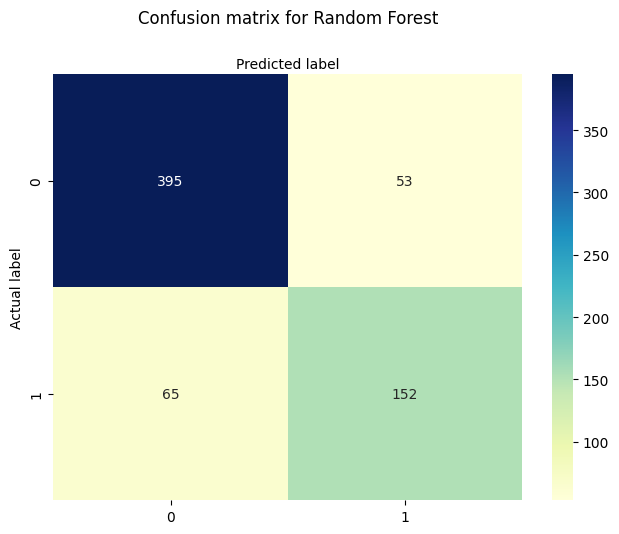

In [142]:
cnf_matrix_RandomForest = metrics.confusion_matrix(Y_test_SVM, Y_Pred_SVMrbf)
cnf_matrix_RandomForest
# name  of classes
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_RandomForest), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix for Random Forest', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
print("Model Accuracy for Random Forest:",metrics.accuracy_score(Y_test_SVM, Y_Pred_SVMrbf))


In [143]:
ac=accuracy_score(Y_test_SVM,Y_Pred_SVMrbf)*100
ac

82.25563909774436

## PCA

Principal Component Analysis(PCA)
PCA is one of the ways to speed up a Machine Learning algorithm so that it fits faster to the training data. There might be a case where the input data or features might be in a higher dimension resulting in slow learning algorithm which takes a long time. To reduce the dimensionality without affecting or loosing any information which can be seen by the variance ratio. One of the aim of PCA is to maximise variance that is, after PCA is applied and if we want to reconstruct the original data back from the principal components, variance or information gained should be maximised or the information lost while doing so minimised.
On our crime dataset, we applied PCA over the Age columns with certain age ranges in order to reduce the feature dimensionality into a 2 dimensional space and plot the features against the label 'violent_crime_occurence' to see the result of applying PCA. The feature set first needs to be standardized and scaled well to give us accurate results. The feature set consists of the following columns from the dataset: 'agePct12t21',''agePct12t29,'agePct16t24'and 'agePct65up'.

In [144]:
from sklearn.model_selection import cross_val_score # Import cross_val_score from model_selection

### Individual feature vs label plots to vizualize data before applying PCA

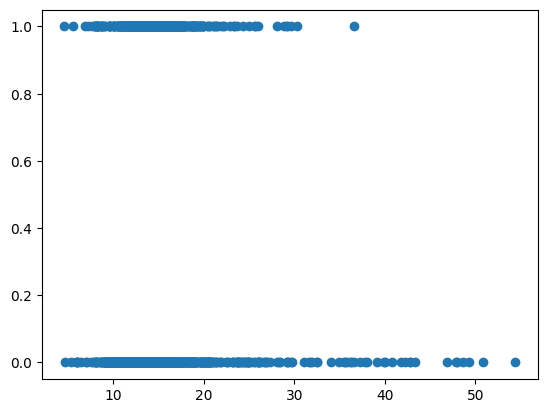

In [145]:
# Reload the original DataFrame to ensure all columns are present
original_df = pd.read_csv('crimedata.csv', sep=',', encoding="ISO-8859-1")

# Create the 'violent_crime_occurence' column if it doesn't exist
if 'violent_crime_occurence' not in original_df.columns:
    # Assuming 'ViolentCrimesPerPop' is the base column
    # Replace '?' with NaN for proper numeric conversion
    original_df['ViolentCrimesPerPop'] = original_df['ViolentCrimesPerPop'].replace('?', np.nan)

    # Calculate the mean excluding NaN values
    violent_crimes = original_df['ViolentCrimesPerPop'].dropna().astype(float)
    violent_crimes_mean = violent_crimes.mean()

    original_df['violent_crime_occurence'] = np.where(
        original_df['ViolentCrimesPerPop'].astype(float) >= violent_crimes_mean, 1, 0
    )

# Now you can access 'agePct12t21' and other columns from the original DataFrame
X3 = original_df['agePct12t21'].values
y3 = original_df['violent_crime_occurence'].values
plt.scatter(X3, y3)
plt.show()

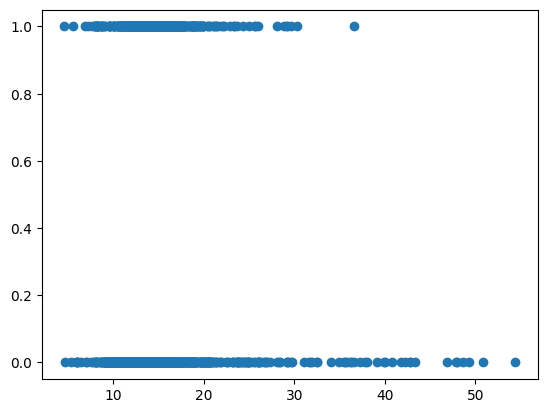

In [146]:
# Reload the original DataFrame to ensure all columns are present
original_df = pd.read_csv('crimedata.csv', sep=',', encoding="ISO-8859-1")

# Create the 'violent_crime_occurence' column if it doesn't exist
if 'violent_crime_occurence' not in original_df.columns:
    # Assuming 'ViolentCrimesPerPop' is the base column
    # Replace '?' with NaN for proper numeric conversion
    original_df['ViolentCrimesPerPop'] = original_df['ViolentCrimesPerPop'].replace('?', np.nan)

    # Calculate the mean excluding NaN values
    violent_crimes = original_df['ViolentCrimesPerPop'].dropna().astype(float)
    violent_crimes_mean = violent_crimes.mean()

    original_df['violent_crime_occurence'] = np.where(
        original_df['ViolentCrimesPerPop'].astype(float) >= violent_crimes_mean, 1, 0
    )

# Now you can access 'agePct12t21' and other columns from the original DataFrame
X4 = original_df['agePct12t21'].values
y4 = original_df['violent_crime_occurence'].values  # Now this should work

plt.scatter(X4, y4)
plt.show()

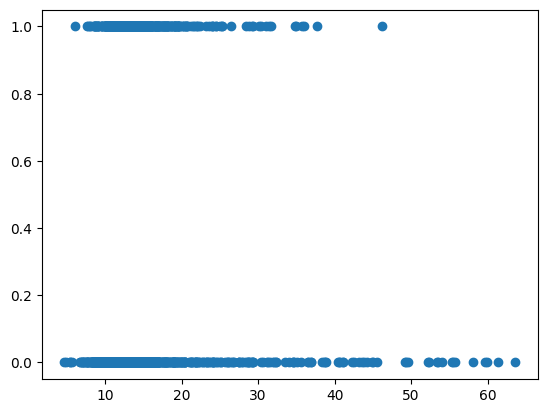

In [147]:
# Reload the original DataFrame to ensure all columns are present
original_df = pd.read_csv('crimedata.csv', sep=',', encoding="ISO-8859-1")

# Create the 'violent_crime_occurence' column if it doesn't exist
if 'violent_crime_occurence' not in original_df.columns:
    # Assuming 'ViolentCrimesPerPop' is the base column
    # Replace '?' with NaN for proper numeric conversion
    original_df['ViolentCrimesPerPop'] = original_df['ViolentCrimesPerPop'].replace('?', np.nan)

    # Calculate the mean excluding NaN values
    violent_crimes = original_df['ViolentCrimesPerPop'].dropna().astype(float)
    violent_crimes_mean = violent_crimes.mean()

    original_df['violent_crime_occurence'] = np.where(
        original_df['ViolentCrimesPerPop'].astype(float) >= violent_crimes_mean, 1, 0
    )

# Now access 'agePct16t24' from the original DataFrame
X5 = original_df['agePct16t24'].values
y5 = original_df['violent_crime_occurence'].values
plt.scatter(X5, y5)
plt.show()

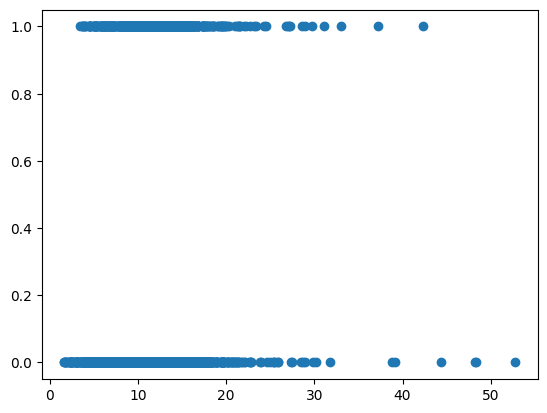

In [148]:
# Reload the original DataFrame to ensure all columns are present
original_df = pd.read_csv('crimedata.csv', sep=',', encoding="ISO-8859-1")

# Create the 'violent_crime_occurence' column if it doesn't exist
if 'violent_crime_occurence' not in original_df.columns:
    # Assuming 'ViolentCrimesPerPop' is the base column
    # Replace '?' with NaN for proper numeric conversion
    original_df['ViolentCrimesPerPop'] = original_df['ViolentCrimesPerPop'].replace('?', np.nan)

    # Calculate the mean excluding NaN values
    violent_crimes = original_df['ViolentCrimesPerPop'].dropna().astype(float)
    violent_crimes_mean = violent_crimes.mean()

    original_df['violent_crime_occurence'] = np.where(
        original_df['ViolentCrimesPerPop'].astype(float) >= violent_crimes_mean, 1, 0
    )

# Now access 'agePct65up' from the original DataFrame
X6 = original_df['agePct65up'].values  # Use original_df instead of df
y6 = original_df['violent_crime_occurence'].values  # Use original_df instead of df
plt.scatter(X6, y6)
plt.show()

### Vizualization Inference

It can be inferred that all the Age range features have similar kind of a relationship with the label and hence could be combined in order to reduce the dimensionality and hence speed up the learning process of a model.

### Feature Selection

In [149]:
# Load original DataFrame or ensure original columns are present
original_df = pd.read_csv('crimedata.csv', sep=',', encoding="ISO-8859-1")  # Assuming 'crimedata.csv' is your original data

# Create the 'violent_crime_occurence' column if it doesn't exist
if 'violent_crime_occurence' not in original_df.columns:
    # Assuming 'ViolentCrimesPerPop' is the base column
    # Replace '?' with NaN for proper numeric conversion
    original_df['ViolentCrimesPerPop'] = original_df['ViolentCrimesPerPop'].replace('?', np.nan)

    # Calculate the mean excluding NaN values
    violent_crimes = original_df['ViolentCrimesPerPop'].dropna().astype(float)
    violent_crimes_mean = violent_crimes.mean()

    original_df['violent_crime_occurence'] = np.where(
        original_df['ViolentCrimesPerPop'].astype(float) >= violent_crimes_mean, 1, 0
    )

# Now you can access 'agePct12t21' and other columns from the original DataFrame
features = ['agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up']
X = original_df.loc[:, features].values  # Use original_df instead of df
y = original_df.loc[:, ['violent_crime_occurence']].values  # Use original_df instead of df

### Splitting Dataset into Test and Training Data


In [150]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Scaling and Standardizing Data

In [151]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Applying PCA from sklearn for 2 Principal Components

In [152]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
principalComponents = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])
explained_variance = pca.explained_variance_ratio_

### Final Dataframe with label concatenated with features

In [153]:
finalDf = pd.concat([principalDf, df[['violent_crime_occurence']]], axis = 1)

### Plot to observe the 2 Principal Components as a result of PCA

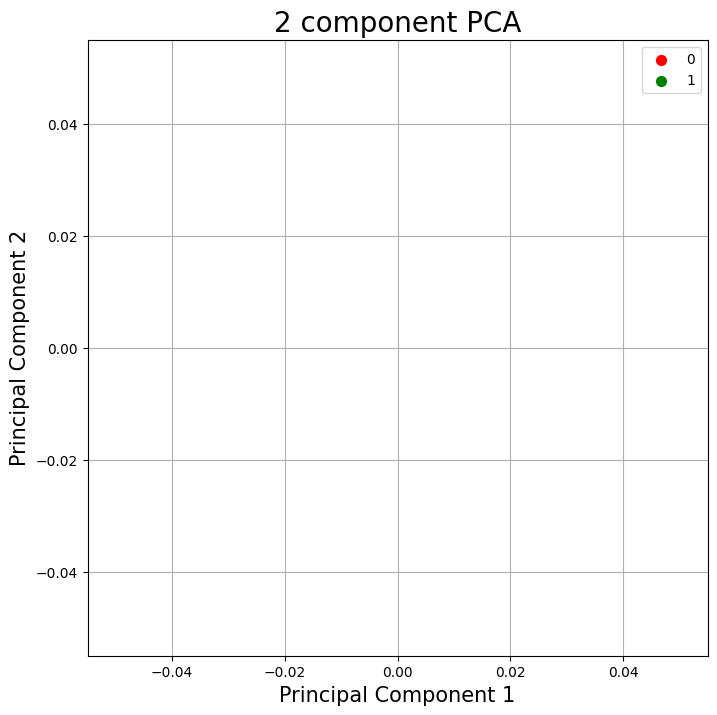

In [154]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)
targets = ['0', '1']
colors = ['r', 'g']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['violent_crime_occurence'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

### Variance Ratio
The variance ratio values are 75.94% and 20.71% meaning that approximately 96% of the information can recontructed from the model and hence the Principal Components are as per model conventions.

In [155]:
print(explained_variance)

[0.75942017 0.20717271]


## KNN

In [156]:
# Load the dataset that you have used to create the 'balance_data' variable
# Assuming 'crimedata.csv' is your original data
original_df = pd.read_csv('crimedata.csv', sep=',', encoding="ISO-8859-1")

# Instead of assuming 'balance_data' exists, create it from original_df
# For example, if 'balance_data' was intended to be the same as original_df:
balance_data = original_df.copy()  # Or use specific columns: balance_data = original_df[['col1', 'col2', ...]]

# Now you can proceed with feature selection
X_KNN = balance_data.iloc[:, [2,6]].values
Y_KNN = balance_data.iloc[:, 12].values

### Splitting the dataset into the Training set and Test set

In [157]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

### Feature Scaling

In [158]:
# Load the dataset that you have used to create the 'balance_data' variable
# Assuming 'crimedata.csv' is your original data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

original_df = pd.read_csv('crimedata.csv', sep=',', encoding="ISO-8859-1")

# Instead of assuming 'balance_data' exists, create it from original_df
# For example, if 'balance_data' was intended to be the same as original_df:
balance_data = original_df.copy()  # Or use specific columns: balance_data = original_df[['col1', 'col2', ...]]

# Now you can proceed with feature selection
# Changed feature selection to use numerical columns
X_KNN = balance_data[['population', 'murders']].values  # Example using 'population' and 'murders' features
Y_KNN = balance_data.iloc[:, 12].values  # Assuming the target variable is in column 12

# Split the data into training and testing sets using train_test_split
X_train_KNN, X_test_KNN, Y_train_KNN, Y_test_KNN = train_test_split(X_KNN, Y_KNN, test_size=0.3, random_state=0) # Adjust test_size and random_state as needed


# Now you can scale the data
sc = StandardScaler()
X_train_KNN = sc.fit_transform(X_train_KNN)
X_test_KNN = sc.transform(X_test_KNN)

### Training and testing the model

In [159]:
# Load the dataset that you have used to create the 'balance_data' variable
# Assuming 'crimedata.csv' is your original data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

original_df = pd.read_csv('crimedata.csv', sep=',', encoding="ISO-8859-1")

# Instead of assuming 'balance_data' exists, create it from original_df
# For example, if 'balance_data' was intended to be the same as original_df:
balance_data = original_df.copy()  # Or use specific columns: balance_data = original_df[['col1', 'col2', ...]]

# Replace '?' with NaN in 'ViolentCrimesPerPop' before conversion
balance_data['ViolentCrimesPerPop'] = balance_data['ViolentCrimesPerPop'].replace('?', np.nan)

# Convert 'ViolentCrimesPerPop' to float, handling NaN values
balance_data['ViolentCrimesPerPop'] = pd.to_numeric(balance_data['ViolentCrimesPerPop'], errors='coerce')

# Now calculate the mean and create 'violent_crime_occurence'
balance_data['violent_crime_occurence'] = (balance_data['ViolentCrimesPerPop'] >= balance_data['ViolentCrimesPerPop'].mean()).astype(int)


# Now you can proceed with feature selection
# Changed feature selection to use numerical columns
X_KNN = balance_data[['population', 'murders']].values  # Example using 'population' and 'murders' features
Y_KNN = balance_data['violent_crime_occurence'].values

# Split the data into training and testing sets using train_test_split
X_train_KNN, X_test_KNN, Y_train_KNN, Y_test_KNN = train_test_split(X_KNN, Y_KNN, test_size=0.3, random_state=0) # Adjust test_size and random_state as needed


# Now you can scale the data
sc = StandardScaler()
X_train_KNN = sc.fit_transform(X_train_KNN)
X_test_KNN = sc.transform(X_test_KNN)

In [160]:
# Load the dataset that you have used to create the 'balance_data' variable
# Assuming 'crimedata.csv' is your original data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier # Import the KNeighborsClassifier

original_df = pd.read_csv('crimedata.csv', sep=',', encoding="ISO-8859-1")

# Instead of assuming 'balance_data' exists, create it from original_df
# For example, if 'balance_data' was intended to be the same as original_df:
balance_data = original_df.copy()  # Or use specific columns: balance_data = original_df[['col1', 'col2', ...]]

# Replace '?' with NaN in 'ViolentCrimesPerPop' before conversion
balance_data['ViolentCrimesPerPop'] = balance_data['ViolentCrimesPerPop'].replace('?', np.nan)

# Convert 'ViolentCrimesPerPop' to float, handling NaN values
balance_data['ViolentCrimesPerPop'] = pd.to_numeric(balance_data['ViolentCrimesPerPop'], errors='coerce')

# Now calculate the mean and create 'violent_crime_occurence'
balance_data['violent_crime_occurence'] = (balance_data['ViolentCrimesPerPop'] >= balance_data['ViolentCrimesPerPop'].mean()).astype(int)


# Now you can proceed with feature selection
# Changed feature selection to use numerical columns
X_KNN = balance_data[['population', 'murders']].values  # Example using 'population' and 'murders' features
Y_KNN = balance_data['violent_crime_occurence'].values

# Split the data into training and testing sets using train_test_split
X_train_KNN, X_test_KNN, Y_train_KNN, Y_test_KNN = train_test_split(X_KNN, Y_KNN, test_size=0.3, random_state=0) # Adjust test_size and random_state as needed


# Now you can scale the data
sc = StandardScaler()
X_train_KNN = sc.fit_transform(X_train_KNN)
X_test_KNN = sc.transform(X_test_KNN)

# Create and fit the KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5) # You can adjust n_neighbors
classifier.fit(X_train_KNN, Y_train_KNN) # Fit the model with training data

# Predicting the Test set results
Y_Pred_KNN = classifier.predict(X_test_KNN)

### Accuracy, Confusion Matrix & Heatmap

In [161]:
ac=accuracy_score(Y_test_KNN,Y_Pred_KNN)*100
ac

78.796992481203

<ipython-input-163-77666e93cf2a>:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


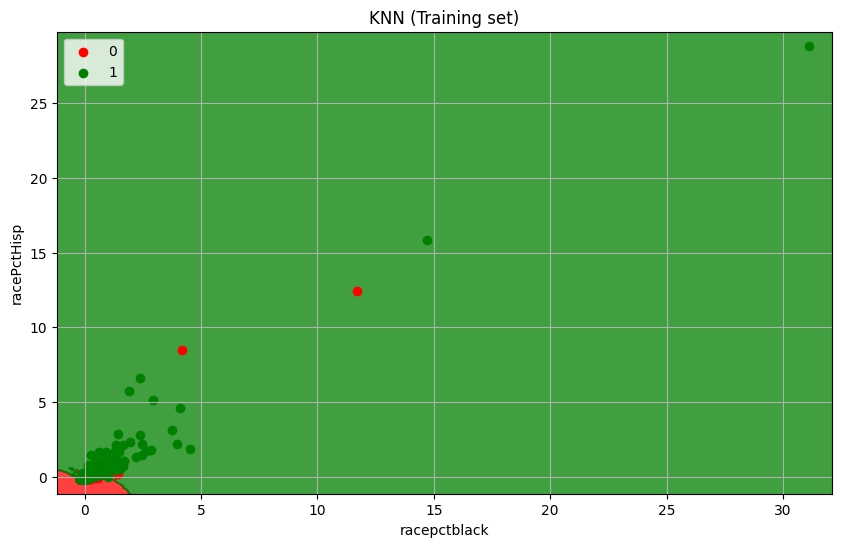

In [163]:
# Visualising the Training set results (Optimized for speed)
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

# Define variables
X_set, y_set = X_train_KNN, Y_train_KNN

# Use a coarser meshgrid to reduce computation time
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.1),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.1)
)

# Predict over the grid more efficiently
grid_points = np.array([X1.ravel(), X2.ravel()]).T
Z = classifier.predict(grid_points).reshape(X1.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plot the actual training points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=j)

# Label and show
plt.title('KNN (Training set)')
plt.xlabel('racepctblack')
plt.ylabel('racePctHisp')
plt.legend()
plt.grid(True)
plt.show()


<ipython-input-165-6f8bafd3d1a8>:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


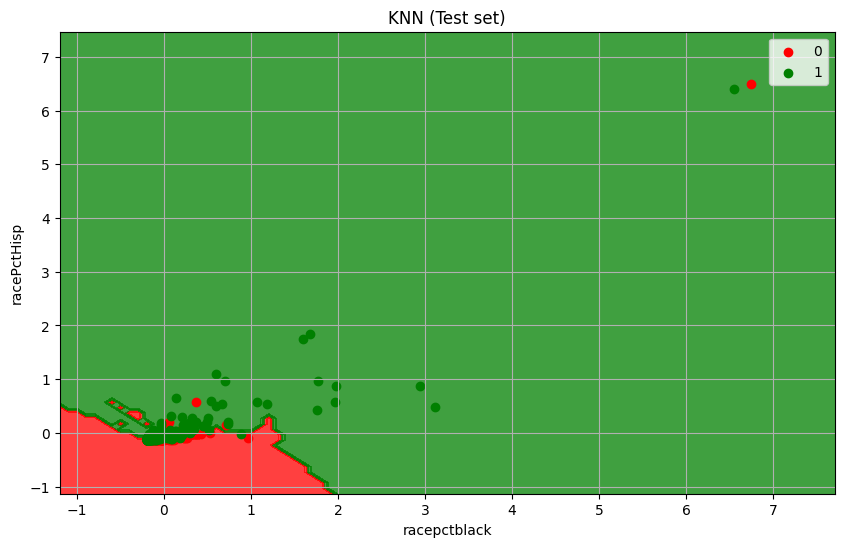

In [165]:
# Visualising the Test set results (Optimized for speed)
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

# Define variables
X_set, y_set = X_test_KNN, Y_test_KNN

# Use a coarser meshgrid for faster execution
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.1),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.1)
)

# Predict over the grid
grid_points = np.array([X1.ravel(), X2.ravel()]).T
Z = classifier.predict(grid_points).reshape(X1.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plot the test data points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=j)

# Label and display
plt.title('KNN (Test set)')
plt.xlabel('racepctblack')
plt.ylabel('racePctHisp')
plt.legend()
plt.grid(True)
plt.show()


Model Accuracy for Random Forest: 0.7879699248120301


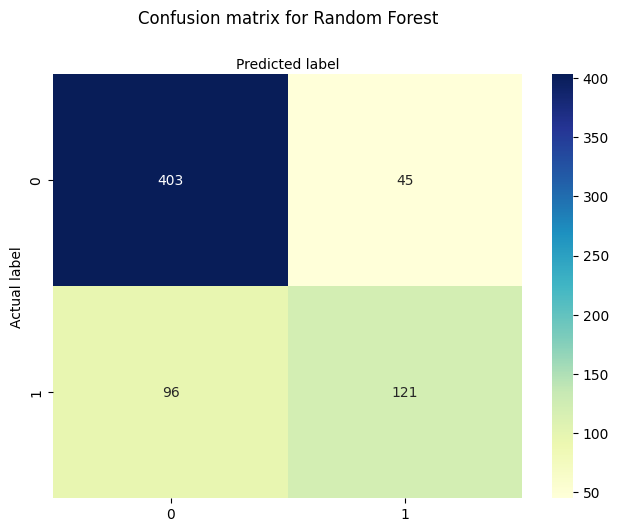

In [166]:
cnf_matrix_RandomForest = metrics.confusion_matrix(Y_test_KNN, Y_Pred_KNN)
cnf_matrix_RandomForest
# name  of classes
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_RandomForest), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix for Random Forest', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
print("Model Accuracy for Random Forest:",metrics.accuracy_score(Y_test_KNN, Y_Pred_KNN))

# Conclusion

The predictions made by various classification algorithms show the occurence possibility of a crime whether a crime will occur or not, if a crime occurs, will it be a violent or a non-violent crime or if a crime occurs, is the cause of the crime murder or not. These predictions might help the local police departments as well as the FBI solve many cases with esfficiency and accuracy.

   Among the classification algorithms, Random Forest Classifier performs the best making a decision based on majority vote and constructing a decision tree for each feature. The highest accuracy achieve with Random Forest Classifier is 86.86%. Also, we observed that the dataset performs well with non-linear data as compared to linear data hence not so good results were achieved with Linear Regression.